L'idée est de tester si la simple représentation sous forme de graphe avec une fonction de coût adaptée fournit les mêmes résultats pour le transport, que ceux obtenus en utilisant les *embeddings*. Cela permet de valider ou pas la pertinence d'une telle approche.

## Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from poincare import PoincareManifold
from model import Distance_PE
from data_utils import *
from OT_utils import *
from information_content import *
from data import *

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


gene_omim :  (2247, 11614)
gene_orpha :  (1700, 11614)
df1_omim : (2247, 8)
 df1_orpha : (1700, 8)


## Chargement des données

In [3]:
# Avec df_omim et df_orpha issus directement de df_hpoa
omim_to_idx = {v: i for i, v in enumerate(df_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(df_orpha['database_id'].values)}

ground_truth = []
for _, row in correspondence_exacte.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

df_gt_set = set(ground_truth)

## Fonction de coût

### Pondération par l'*Information Content*

In [6]:
weights, _, _ = compute_information_content(df_omim, G_hpo_work)
weights = {t:1/w for t, w in weights.items()}

In [6]:
def cost_matrix_hamm(df_omim, df_orpha, weights, block_size=256):
    n = df_omim.shape[0]
    m = df_orpha.shape[0]
    C = np.zeros((n, m))

    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    all_hpo = list(hpo_cols)
    weights_vector = np.array([weights.get(hp, 0.0) for hp in all_hpo])

    omim_matrix = df_omim.reindex(columns=all_hpo, fill_value=0)[all_hpo].values.astype(float)
    orpha_matrix = df_orpha.reindex(columns=all_hpo,  fill_value=0)[all_hpo].values.astype(float)
    
    for i_start in tqdm(range(0, n, block_size)):
        i_end = min(i_start + block_size, n)
        block = omim_matrix[i_start:i_end]
        diff = np.abs(block[:, None, :] - orpha_matrix[None, :, :])
        C[i_start:i_end] = (diff * weights_vector).sum(axis=2)
    return C

In [7]:
C = cost_matrix_hamm(df_omim, df_orpha, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:46<00:00, 35.43s/it]

======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.702 (386/550)
Top-3 accuracy : 0.705 (388/550)
Top-5 accuracy : 0.705 (388/550)
 Rang moyen: 76.23
======== Avec régularisation ========
17913.730145857426
Paires évaluées : 550
Top-1 accuracy : 0.693 (381/550)
Top-3 accuracy : 0.825 (454/550)
Top-5 accuracy : 0.853 (469/550)
 Rang moyen: 16.36


### Pondération par la profondeur des noeuds dans le graphe

In [8]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(df_omim, df_orpha, depths)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C1)

100%|██████████| 3/3 [01:50<00:00, 36.88s/it]


======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.824 (453/550)
Top-5 accuracy : 0.824 (453/550)
 Rang moyen: 49.14
======== Avec régularisation ========
3.8610095206611574
Paires évaluées : 550
Top-1 accuracy : 0.842 (463/550)
Top-3 accuracy : 0.900 (495/550)
Top-5 accuracy : 0.911 (501/550)
 Rang moyen: 5.58


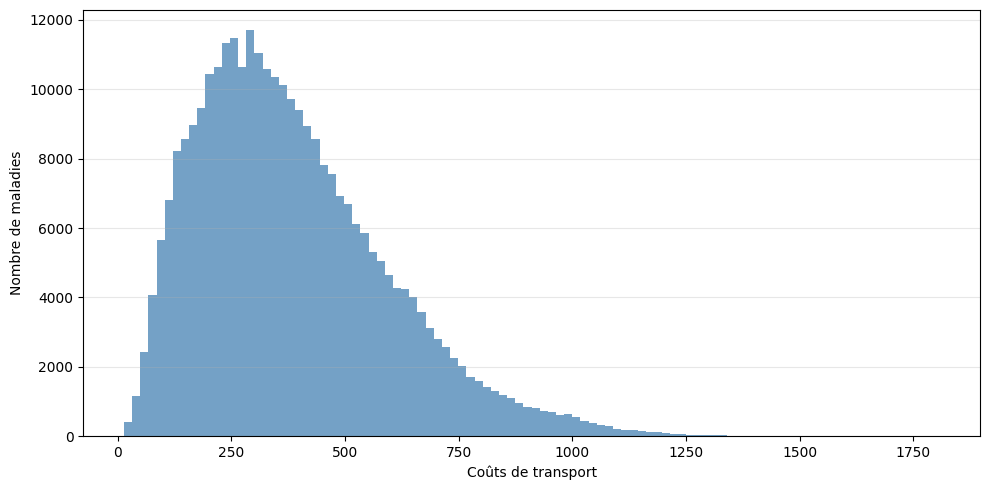

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(C1.ravel(), bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Coûts de transport")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Etude (rapide) des maladies incorrectement transportées

118/495


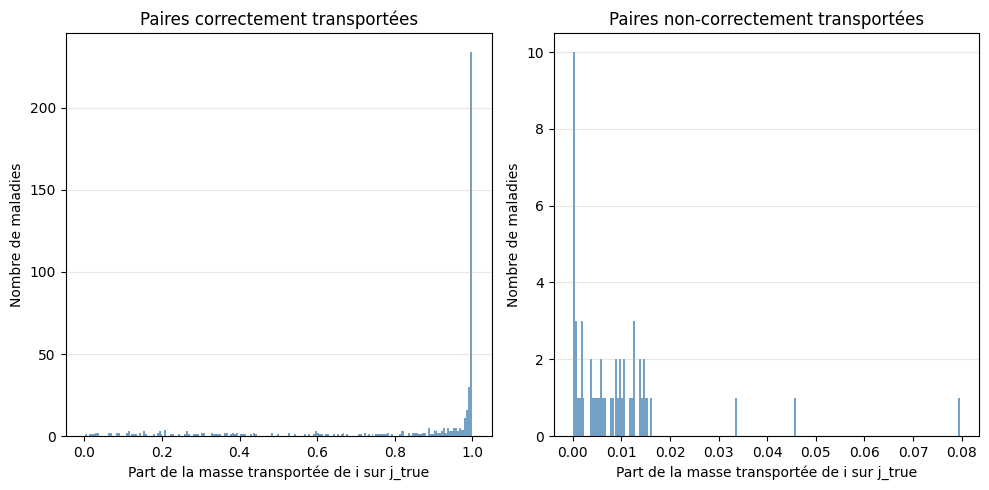

In [ ]:
pairs_zero = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]
correct_pairs = [k for k, v in pairs_reg.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
print(f"{len([v for v in correct_transported_share if v < 0.8])}/{len(correct_transported_share)}")
uncorrect_transported_share = [v for k, v in transported_share.items() if k in pairs_zero]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
dict_ranks_w = {}
for i, k in enumerate(pairs_reg.keys()):
    dict_ranks_w[k]=ranks_reg[i]

pairs_zero_dict = {}
hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}
for (i,j) in  pairs_zero:
    j_pred = np.argmax(ot_plan_reg[i])
    omim_row = df_omim.iloc[i][hpo_cols]
    orpha_row = df_orpha.iloc[j][hpo_cols]
    orpha_row_pred = df_orpha.iloc[j_pred][hpo_cols]
    
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    orpha_pred_hpos = orpha_row_pred[orpha_row_pred==1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    pairs_zero_dict[(i, j)] = {
        "rank": dict_ranks_w[(i,j)],
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
        "cost_true": C1[i, j],
        "cost_pred": C1[i, j_pred],
        "predicted_disease" : pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j_pred]]['disease_name'])[0],
        "count_pred" : len(orpha_pred_hpos),
        "terms pred" : orpha_pred_hpos
    }

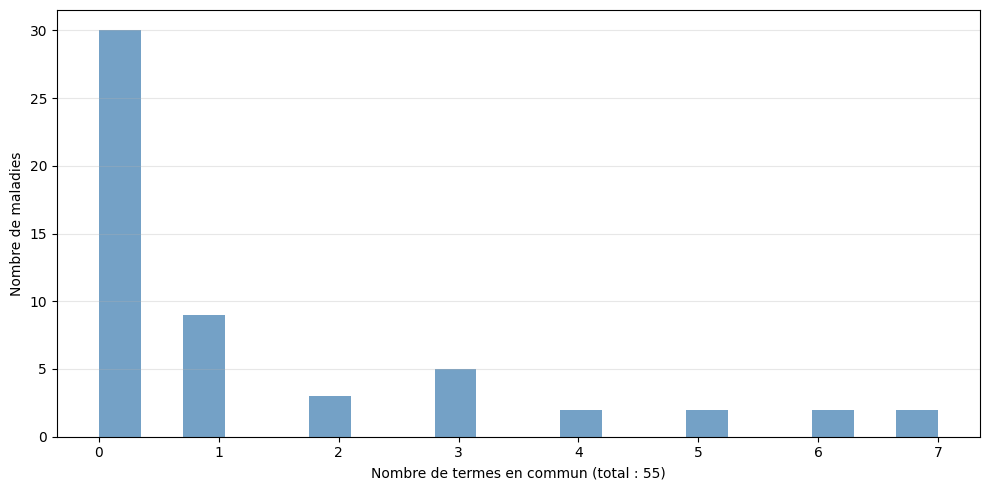

In [11]:
# Termes HP en commun parmi les maladies non associées
communs_w = np.array([len(v['commun'])  for v in pairs_zero_dict.values()])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(communs_w, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes en commun (total : {len(communs_w)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

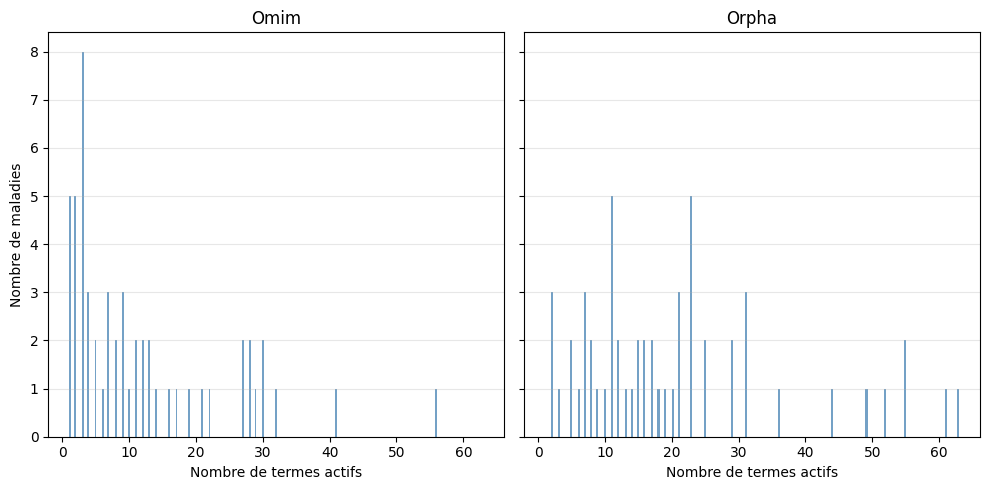

In [12]:
# Nombre de termes omim dans les maladies que l'on ne retrouve pas
omim_counts = np.array([v['omim']['count']  for v in pairs_zero_dict.values()])
orpha_counts = np.array([v['orpha']['count'] for v in pairs_zero_dict.values()])


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(omim_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(orpha_counts, bins=200, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
df = pd.read_csv("../data/utils/paires_zero_wass.csv")

paires_zero_dict_wass = {}
for _, row in df.iterrows():
    key = (row["i"], row["j"])
    paires_zero_dict_wass[key] = {
        "rank": row["rank"],
        "omim": {
            "name": row["omim_name"],
            "count": row["omim_count"],
            "terms": row["omim_terms"].split("|")
        },
        "orpha": {
            "name": row["orpha_name"],
            "count": row["orpha_count"],
            "terms": row["orpha_terms"].split("|")
        },
        "commun": set(row["commun"].split("|")) if pd.notna(row["commun"]) else set(),
        "cost_true": row["cost_true"],
        "cost_pred": row["cost_pred"],
        "terms_pred": row["terms_pred"]
    }

In [30]:
print("Maladies mal associées dans les deux cas :", len(set(paires_zero_dict_wass.keys())& set(pairs_zero_dict.keys())))
print(len(paires_zero_dict_wass.keys()))
print(len(pairs_zero_dict.keys()))

inter = set(paires_zero_dict_wass.keys()) & set(pairs_zero_dict.keys())
comp = {k:v for k, v in pairs_zero_dict.items() if k not in inter}
intersect = {k:v for k,v in pairs_zero_dict.items() if k in inter}
print(np.median(sorted([intersect[k]["rank"] for k in intersect.keys()])))
print(np.median(sorted([comp[k]["rank"] for k in comp.keys()])))

Maladies mal associées dans les deux cas : 25
46
55
32.0
15.0


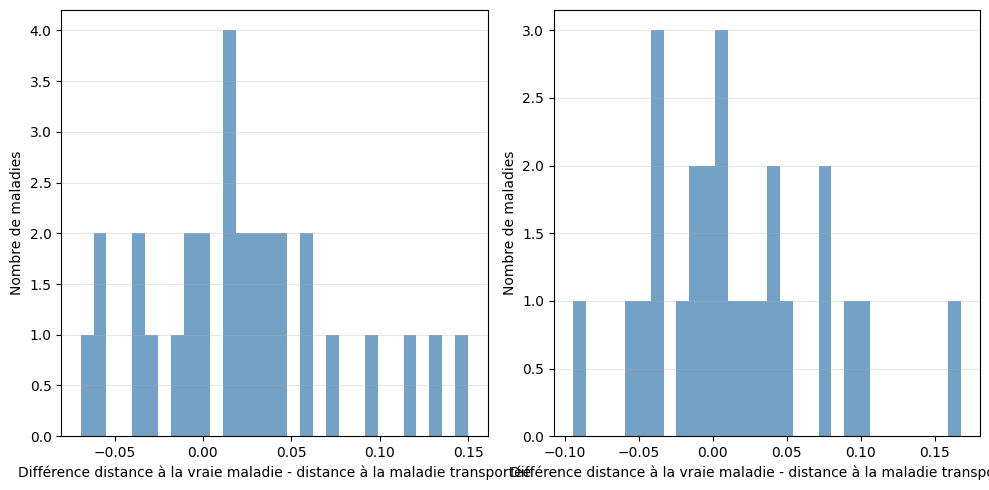

In [37]:
cost_gap_comp = [(comp[k]["cost_true"]-comp[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in comp.keys()]
cost_gap_inter = [(intersect[k]["cost_true"]-intersect[k]["cost_pred"])/(np.max(C1.ravel())-np.min(C1.ravel())) for k in intersect.keys()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]

sns.histplot(cost_gap_comp, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(cost_gap_inter, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Différence distance à la vraie maladie - distance à la maladie transportée")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Distances de Jaccard, $l_2$, Hamming non pondérées

In [12]:
# Distance euclidienne
C = basic_cost_matrix(df_omim, df_orpha, 'euclidean')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.760 (418/550)
Top-3 accuracy : 0.762 (419/550)
Top-5 accuracy : 0.762 (419/550)
 Rang moyen: 64.54
======== Avec régularisation ========
0.07462939636320927
Paires évaluées : 550
Top-1 accuracy : 0.778 (428/550)
Top-3 accuracy : 0.838 (461/550)
Top-5 accuracy : 0.849 (467/550)
 Rang moyen: 13.56


In [13]:
# Distance Jaccard
C = basic_cost_matrix(df_omim, df_orpha, 'jaccard')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.804 (442/550)
Top-3 accuracy : 0.805 (443/550)
Top-5 accuracy : 0.805 (443/550)
 Rang moyen: 50.95
======== Avec régularisation ========
0.009850633357655946
Paires évaluées : 550
Top-1 accuracy : 0.822 (452/550)
Top-3 accuracy : 0.902 (496/550)
Top-5 accuracy : 0.916 (504/550)
 Rang moyen: 5.96


In [15]:
# Distance Hamming
C = basic_cost_matrix(df_omim, df_orpha, 'hamming')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, df_gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, df_gt_set, C)

Check : (550, 550)
======== Sans régularisation ========
Paires évaluées : 550
Top-1 accuracy : 0.829 (456/550)
Top-3 accuracy : 0.831 (457/550)
Top-5 accuracy : 0.831 (457/550)
 Rang moyen: 47.36
======== Avec régularisation ========
5.143756676224209e-05
Paires évaluées : 550
Top-1 accuracy : 0.835 (459/550)
Top-3 accuracy : 0.904 (497/550)
Top-5 accuracy : 0.913 (502/550)
 Rang moyen: 5.83


Nombres de maladies correctement transportées, mais à moins de 80% de masse : 116/497


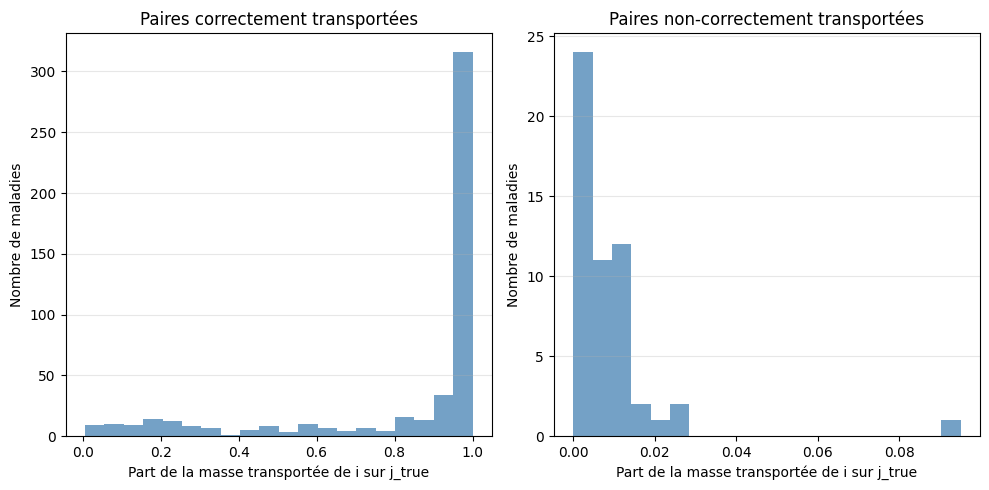

In [18]:
pairs_zero = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]
correct_pairs = [k for k, v in pairs_reg.items() if (v[0]>=1 and v[0]<=3)]
marginal = np.sum(ot_plan_reg, axis=1)
transported_share = {}
for (i, j_true) in df_gt_set:
    transported_share[(i, j_true)]=ot_plan_reg[i, j_true]/marginal[i]

correct_transported_share = [v for k, v in transported_share.items() if k in correct_pairs]
print(f"Nombres de maladies correctement transportées, mais à moins de 80% de masse : {len([v for v in correct_transported_share if v < 0.8])}/{len(correct_transported_share)}")
uncorrect_transported_share = [v for k, v in transported_share.items() if k in pairs_zero]

fig, axes = plt.subplots(1, 2, figsize=(10, 5),)

ax = axes[0]
sns.histplot(correct_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires correctement transportées")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(uncorrect_transported_share, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de la masse transportée de i sur j_true")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Paires non-correctement transportées")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

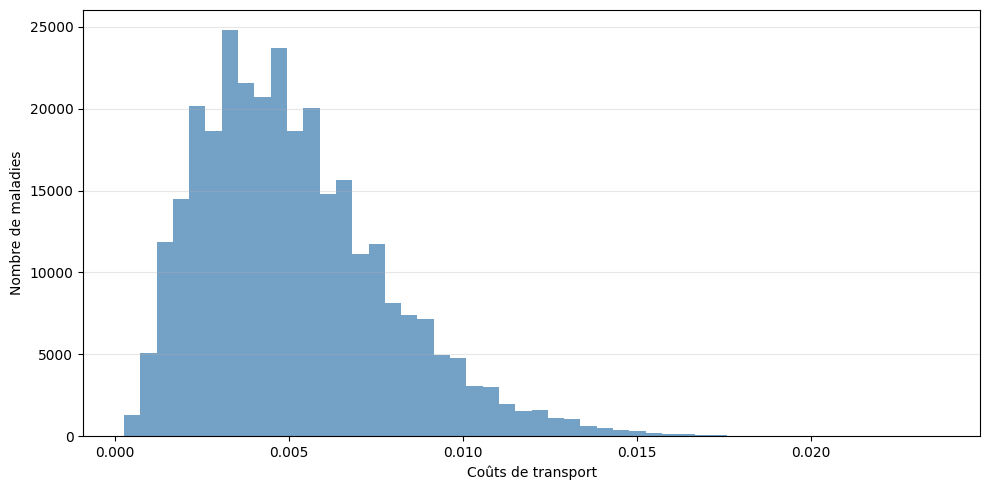

In [23]:
# Distribution du coût de transport
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(C.ravel(), bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Coûts de transport")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
np.var(C, axis=1)/np.mean(C, axis=1)

array([0.00085887, 0.00051003, 0.00026571, 0.00045399, 0.00063361,
       0.00069262, 0.00079886, 0.0003585 , 0.00124864, 0.00094767,
       0.00071375, 0.0012857 , 0.00046337, 0.00121572, 0.00117418,
       0.0011455 , 0.00092635, 0.0010599 , 0.00095004, 0.00096188,
       0.00121407, 0.00094507, 0.00108183, 0.00024496, 0.00051035,
       0.00073259, 0.00024627, 0.00044272, 0.00081626, 0.00127407,
       0.00041166, 0.00117829, 0.00121146, 0.00109484, 0.00074802,
       0.00113017, 0.00095781, 0.00039664, 0.00089177, 0.00061327,
       0.0008659 , 0.00111365, 0.00124997, 0.00128653, 0.0009973 ,
       0.00128604, 0.00062335, 0.00037936, 0.00066482, 0.00097346,
       0.00120808, 0.00121599, 0.00037075, 0.00071111, 0.00098611,
       0.0011481 , 0.00033835, 0.00077924, 0.00104096, 0.00112019,
       0.00109478, 0.00064229, 0.00113683, 0.00093378, 0.00023558,
       0.00120768, 0.00095289, 0.00104041, 0.00028881, 0.0009271 ,
       0.00125056, 0.0007934 , 0.000326  , 0.00105833, 0.00061

## Correspondances gènes-maladies

In [2]:
omim_to_idx = {v: i for i, v in enumerate(gene_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(gene_orpha['database_id'].values)}

ground_truth = []
for _, row in df_gene_correspondence0.iterrows():
    if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
        i = omim_to_idx[row['omim_id']]
        j = orpha_to_idx[row['orpha_id']]
        ground_truth.append((i, j))

gene_gt_set = set(ground_truth)

### Distances simples $l_2$, Jaccard, Hamming

In [6]:
# Distances de base
for dist_method in ['euclidean', 'jaccard', 'hamming']:
    print(dist_method)
    C = basic_cost_matrix(gene_omim, gene_orpha, dist_method)

    # Sans régularisation
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C, a=None, b=None)
    ranks, pairs = evaluate_transport(ot_plan, gene_gt_set, C)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[0] * np.mean(C)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gene_gt_set, C)
    print("")

euclidean
Check : (2247, 1700)
======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.269 (1027/3823)
Top-3 accuracy : 0.304 (1163/3823)
Top-5 accuracy : 0.307 (1173/3823)
 Rang moyen: 583.37
======== Avec régularisation ========
0.07042204352446957
Paires évaluées : 3823
Top-1 accuracy : 0.281 (1075/3823)
Top-3 accuracy : 0.355 (1358/3823)
Top-5 accuracy : 0.385 (1473/3823)
 Rang moyen: 307.33

jaccard
Check : (2247, 1700)
======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.284 (1086/3823)
Top-3 accuracy : 0.321 (1227/3823)
Top-5 accuracy : 0.325 (1243/3823)
 Rang moyen: 566.53
======== Avec régularisation ========
0.009870020906453445
Paires évaluées : 3823
Top-1 accuracy : 0.293 (1121/3823)
Top-3 accuracy : 0.376 (1436/3823)
Top-5 accuracy : 0.412 (1575/3823)
 Rang moyen: 284.73

hamming
Check : (2247, 1700)
======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.279 (1066/3823)
Top-3 accuracy : 0.319 (1219

### Distances pondérées en exploitant juste la structure d'arbre 

In [3]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(gene_omim, gene_orpha, depths)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gene_gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gene_gt_set, C1)

======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.281 (1073/3823)
Top-3 accuracy : 0.318 (1216/3823)
Top-5 accuracy : 0.323 (1233/3823)
 Rang moyen: 569.93
======== Avec régularisation ========
3.3697089347888687
Paires évaluées : 3823
Top-1 accuracy : 0.291 (1113/3823)
Top-3 accuracy : 0.369 (1410/3823)
Top-5 accuracy : 0.403 (1541/3823)
 Rang moyen: 261.02


In [5]:
weights, _, _ = compute_information_content(gene_omim, G_hpo_work)
weights = {t:-np.log(w) for t, w in weights.items()}

C1 = cost_matrix_hamm(gene_omim, gene_orpha, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gene_gt_set, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gene_gt_set, C1)

======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.286 (1094/3823)
Top-3 accuracy : 0.323 (1233/3823)
Top-5 accuracy : 0.327 (1251/3823)
 Rang moyen: 566.59
======== Avec régularisation ========
4.8996848669012385
Paires évaluées : 3823
Top-1 accuracy : 0.295 (1128/3823)
Top-3 accuracy : 0.378 (1445/3823)
Top-5 accuracy : 0.414 (1581/3823)
 Rang moyen: 258.24


### Distances qui exploitent l'*embedding*

In [3]:
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)
hp = checkpoint['hyperparams']
objects = checkpoint['objects']
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [4]:
C_jacc = compute_cost_matrix_pseudo_jacc(gene_omim, gene_orpha, node2id_w, model)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_jacc, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gene_gt_set, C_jacc)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C_jacc)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_jacc, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gene_gt_set, C_jacc)

Compute norms
Norms computed !
C[0,0]  ref=198.891600  new=198.891600  diff=2.84e-14
C[3,7]  ref=469.457025  new=469.457025  diff=5.68e-14
C[9,14]  ref=269.139447  new=269.139447  diff=5.68e-14
======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.280 (1072/3823)
Top-3 accuracy : 0.315 (1204/3823)
Top-5 accuracy : 0.319 (1218/3823)
 Rang moyen: 572.67
======== Avec régularisation ========
2.1391678127668414
Paires évaluées : 3823
Top-1 accuracy : 0.290 (1110/3823)
Top-3 accuracy : 0.370 (1414/3823)
Top-5 accuracy : 0.407 (1556/3823)
 Rang moyen: 258.13


In [5]:
C_wass = compute_costs_matrix_wasserstein2(gene_omim, gene_orpha, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gene_gt_set, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[0] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gene_gt_set, C_wass)

Precompute...
Finished !
Precomputing full HPO distance matrix...
HPO distance matrix: (8343, 8343)


OMIM: 100%|██████████| 2247/2247 [04:08<00:00,  9.04it/s]


======== Sans régularisation ========
Paires évaluées : 3823
Top-1 accuracy : 0.245 (936/3823)
Top-3 accuracy : 0.287 (1098/3823)
Top-5 accuracy : 0.292 (1115/3823)
 Rang moyen: 596.91
======== Avec régularisation ========
0.011507792210356596
Paires évaluées : 3823
Top-1 accuracy : 0.250 (955/3823)
Top-3 accuracy : 0.340 (1300/3823)
Top-5 accuracy : 0.380 (1451/3823)
 Rang moyen: 283.53


### Ajout d'une régularisation Laplacienne en utilisant les PPI

On considère que deux maladies sont similaires si leurs protéines interagissent ensemble.

In [13]:
def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = {row['protein']: i for i, row in df.iterrows()}

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            j = protein_to_idx.get(p)
            if j is not None :
                S[i, j]=1
                S[j, i]=1
    return S

simi_source = simi_ppi(df1_omim)
simi_target = simi_ppi(df1_orpha)